# Klasifikimi dhe Grupimi i Kurseve Online (Udemy)
**Projekt — Machine Learning**

**Problemi:** parashikimi i lëndës (*subject*) së një kursi online duke u bazuar në atributet e tij (çmimi, numri i studentëve, numri i leksioneve, niveli, etj.), si dhe grupimi i kurseve pa etiketa për të zbuluar struktura natyrore në treg.

**Dataseti:** [Udemy Online Education Courses (Kaggle)](https://www.kaggle.com/datasets/yusufdelikkaya/udemy-online-education-courses) — 3,683 kurse reale, 4 klasa: *Web Development, Business Finance, Musical Instruments, Graphic Design*.

**Klasifikuesit (4 familje të ndryshme):**
1. **KNN** — i bazuar në distancë
2. **Random Forest** — i bazuar në pemë vendimmarrëse
3. **Logistic Regression** — linear
4. **MLP (rrjetë neurale)** — me 2 arkitektura të ndryshme

**Grupimi:** K-Means (+ krahasim me Agglomerative), vlerësuar kundrejt etiketave reale me ARI/NMI.

In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             adjusted_rand_score, normalized_mutual_info_score, silhouette_score)
from sklearn.cluster import KMeans, AgglomerativeClustering

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 110
RESULTS = {}  # collected for the report

## 1. Ngarkimi dhe eksplorimi i të dhënave (EDA)

In [2]:
df = pd.read_csv('data/udemy_courses.csv')
print('Forma:', df.shape)
df.head(3)

Forma: (3678, 12)


,course_id,course_title,url,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,1070968,Ultimate Investment Banking Course,https://www.udemy.com/ultimate-investment-bank...,True,200,2147,23,51,All Levels,1.5,2017-01-18T20:58:58Z,Business Finance
1,1113822,Complete GST Course & Certification - Grow You...,https://www.udemy.com/goods-and-services-tax/,True,75,2792,923,274,All Levels,39.0,2017-03-09T16:34:20Z,Business Finance
2,1006314,Financial Modeling for Business Analysts and C...,https://www.udemy.com/financial-modeling-for-b...,True,45,2174,74,51,Intermediate Level,2.5,2016-12-19T19:26:30Z,Business Finance


subject
Web Development        1200
Business Finance       1195
Musical Instruments     680
Graphic Design          603
Name: count, dtype: int64


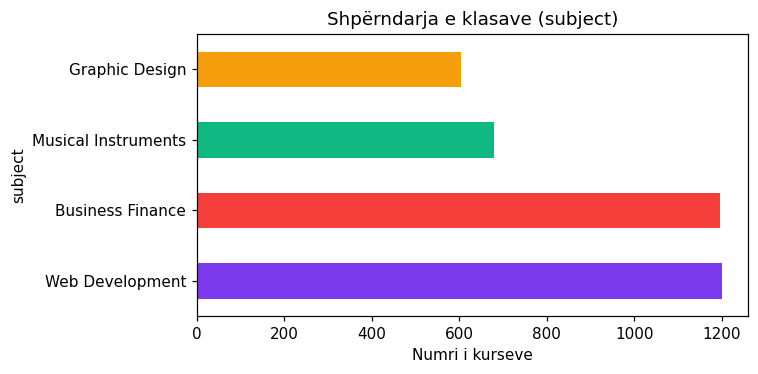

In [3]:
# Shpërndarja e klasave
counts = df['subject'].value_counts()
print(counts)
fig, ax = plt.subplots(figsize=(7,3.5))
counts.plot(kind='barh', color=['#7c3aed','#f43f3a','#10b981','#f59e0b'], ax=ax)
ax.set_xlabel('Numri i kurseve'); ax.set_title('Shpërndarja e klasave (subject)')
plt.tight_layout(); plt.savefig('figures/class_distribution.png'); plt.show()
RESULTS['class_counts'] = counts.to_dict()

In [4]:
df[['price','num_subscribers','num_reviews','num_lectures','content_duration']].describe().round(1)

,price,num_subscribers,num_reviews,num_lectures,content_duration
count,3678.0,3678.0,3678.0,3678.0,3678.0
mean,66.0,3197.2,156.3,40.1,4.1
std,61.0,9504.1,935.5,50.4,6.1
min,0.0,0.0,0.0,0.0,0.0
25%,20.0,111.0,4.0,15.0,1.0
50%,45.0,911.5,18.0,25.0,2.0
75%,95.0,2546.0,67.0,45.8,4.5
max,200.0,268923.0,27445.0,779.0,78.5


## 2. Parapërpunimi i të dhënave

Hapat: largimi i duplikatave, konvertimi i `is_paid` në numerik, kodimi ordinal i `level`, nxjerrja e vitit nga `published_timestamp`. Veçoritë numerike standardizohen (StandardScaler) — e domosdoshme për KNN, LR dhe MLP.

In [5]:
df = df.drop_duplicates(subset='course_id').reset_index(drop=True)

level_map = {'Beginner Level':1, 'Intermediate Level':2, 'Expert Level':3, 'All Levels':0}
df['level_enc'] = df['level'].map(level_map)
df['is_paid'] = df['is_paid'].astype(str).str.lower().eq('true').astype(int)
df['year'] = pd.to_datetime(df['published_timestamp']).dt.year

NUMERIC = ['price','num_subscribers','num_reviews','num_lectures','content_duration','level_enc','is_paid','year']
X_num = df[NUMERIC].values
le = LabelEncoder()
y = le.fit_transform(df['subject'])  # etiketa numerike; emrat te le.classes_
CLASS_NAMES = le.classes_
print('Pas pastrimit:', df.shape, '| Veçori numerike:', len(NUMERIC))

Pas pastrimit: (3672, 14) | Veçori numerike: 8


In [6]:
# Ndarja stratifikuar 80/20 — e njëjta ndarje përdoret për të gjitha eksperimentet
idx_tr, idx_te = train_test_split(np.arange(len(df)), test_size=0.2,
                                  stratify=y, random_state=RANDOM_STATE)
scaler = StandardScaler().fit(X_num[idx_tr])
Xn_tr, Xn_te = scaler.transform(X_num[idx_tr]), scaler.transform(X_num[idx_te])
y_tr, y_te = y[idx_tr], y[idx_te]
print('Trajnim:', Xn_tr.shape, '| Testim:', Xn_te.shape)

Trajnim: (2937, 8) | Testim: (735, 8)


## 3. Inxhinieria dhe përzgjedhja e veçorive

Tre eksperimente:
- **A. Vetëm veçori numerike** (8 veçori) — baseline
- **B. Përzgjedhje veçorish** me `SelectKBest` (ANOVA F) — a mjaftojnë më pak veçori?
- **C. Veçori tekstuale nga titulli** — TF-IDF mbi `course_title`, reduktuar me TruncatedSVD në 50 dimensione (reduktim dimensionaliteti), të kombinuara me veçoritë numerike.

In [7]:
# B: SelectKBest — renditja e veçorive sipas ANOVA F-score
skb = SelectKBest(f_classif, k='all').fit(Xn_tr, y_tr)
order = np.argsort(skb.scores_)[::-1]
print('Renditja e veçorive (F-score):')
for i in order: print(f"  {NUMERIC[i]:18s} F = {skb.scores_[i]:9.1f}")
RESULTS['feature_scores'] = {NUMERIC[i]: round(float(skb.scores_[i]),1) for i in order}
TOP4 = [NUMERIC[i] for i in order[:4]]
sel4 = [NUMERIC.index(f) for f in TOP4]
print('Top-4:', TOP4)

Renditja e veçorive (F-score):
  num_subscribers    F =      86.5
  num_lectures       F =      30.7
  content_duration   F =      29.2
  num_reviews        F =      27.3
  price              F =      25.7
  level_enc          F =       6.9
  is_paid            F =       5.6
  year               F =       5.3
Top-4: ['num_subscribers', 'num_lectures', 'content_duration', 'num_reviews']


In [8]:
# C: TF-IDF mbi tituj + SVD(50), kombinuar me numerike
tfidf = TfidfVectorizer(max_features=2000, stop_words='english', ngram_range=(1,2))
T_tr = tfidf.fit_transform(df['course_title'].iloc[idx_tr])
T_te = tfidf.transform(df['course_title'].iloc[idx_te])
svd = TruncatedSVD(n_components=50, random_state=RANDOM_STATE).fit(T_tr)
Xc_tr = np.hstack([Xn_tr, svd.transform(T_tr)])
Xc_te = np.hstack([Xn_te, svd.transform(T_te)])
print('Bashkësia C:', Xc_tr.shape, '— 8 numerike + 50 komponentë SVD nga titulli')

Bashkësia C: (2937, 58) — 8 numerike + 50 komponentë SVD nga titulli


## 4. Klasifikimi — rregullimi i hiperparametrave (GridSearchCV, 3-fold)

Për çdo klasifikues testohen disa vlera hiperparametrash; raportohen vlerat e provuara dhe ato të zgjedhura. MLP testohet me **dy arkitektura**: `(64,)` — një shtresë e fshehur, dhe `(128, 64)` — dy shtresa, të dyja me aktivizim ReLU dhe optimizues Adam.

In [9]:
GRIDS = {
  'KNN': (KNeighborsClassifier(), {'n_neighbors':[3,5,7,11,15], 'weights':['uniform','distance']}),
  'Random Forest': (RandomForestClassifier(random_state=RANDOM_STATE),
                    {'n_estimators':[100,200], 'max_depth':[None,10,20]}),
  'Logistic Regression': (LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                          {'C':[0.1,1,10]}),
  'MLP (NN)': (MLPClassifier(max_iter=400, early_stopping=True, random_state=RANDOM_STATE),
               {'hidden_layer_sizes':[(64,),(128,64)], 'alpha':[1e-4,1e-3]}),
}

def run_models(Xtr, Xte, tag):
    rows = {}
    for name,(est,grid) in GRIDS.items():
        gs = GridSearchCV(est, grid, cv=3, scoring='f1_macro', n_jobs=-1).fit(Xtr, y_tr)
        pred = gs.predict(Xte)
        rows[name] = {
            'best_params': gs.best_params_,
            'cv_f1': round(gs.best_score_,4),
            'accuracy': round(accuracy_score(y_te,pred),4),
            'precision': round(precision_score(y_te,pred,average='macro'),4),
            'recall': round(recall_score(y_te,pred,average='macro'),4),
            'f1': round(f1_score(y_te,pred,average='macro'),4),
        }
        print(f"[{tag}] {name:20s} acc={rows[name]['accuracy']:.3f} f1={rows[name]['f1']:.3f}  best={gs.best_params_}")
    return rows

In [10]:
print('=== A: 8 veçori numerike ===')
res_A = run_models(Xn_tr, Xn_te, 'A')

=== A: 8 veçori numerike ===


[A] KNN                  acc=0.505 f1=0.472  best={'n_neighbors': 7, 'weights': 'distance'}


[A] Random Forest        acc=0.565 f1=0.506  best={'max_depth': 20, 'n_estimators': 200}
[A] Logistic Regression  acc=0.472 f1=0.360  best={'C': 10}


[A] MLP (NN)             acc=0.540 f1=0.467  best={'alpha': 0.0001, 'hidden_layer_sizes': (128, 64)}


In [11]:
print('=== B: Top-4 veçori (SelectKBest) ===')
res_B = run_models(Xn_tr[:,sel4], Xn_te[:,sel4], 'B')

=== B: Top-4 veçori (SelectKBest) ===


[B] KNN                  acc=0.440 f1=0.395  best={'n_neighbors': 7, 'weights': 'distance'}


[B] Random Forest        acc=0.488 f1=0.426  best={'max_depth': None, 'n_estimators': 200}
[B] Logistic Regression  acc=0.468 f1=0.340  best={'C': 10}


[B] MLP (NN)             acc=0.480 f1=0.351  best={'alpha': 0.0001, 'hidden_layer_sizes': (128, 64)}


In [12]:
print('=== C: numerike + TF-IDF(titull)→SVD ===')
res_C = run_models(Xc_tr, Xc_te, 'C')
RESULTS['experiments'] = {'A_numeric8': res_A, 'B_top4': res_B, 'C_text': res_C}

=== C: numerike + TF-IDF(titull)→SVD ===


[C] KNN                  acc=0.608 f1=0.594  best={'n_neighbors': 3, 'weights': 'distance'}


[C] Random Forest        acc=0.922 f1=0.913  best={'max_depth': None, 'n_estimators': 100}


[C] Logistic Regression  acc=0.929 f1=0.920  best={'C': 10}


[C] MLP (NN)             acc=0.914 f1=0.902  best={'alpha': 0.0001, 'hidden_layer_sizes': (128, 64)}


### Krahasimi i bashkësive të veçorive

Tabela tregon F1-macro në bashkësinë e testimit për secilin klasifikues nëpër tre bashkësitë e veçorive.

,A: 8 numerike,B: top-4,C: + titull (TF-IDF)
KNN,0.472,0.394,0.594
Random Forest,0.506,0.426,0.913
Logistic Regression,0.360,0.340,0.920
MLP (NN),0.467,0.351,0.902


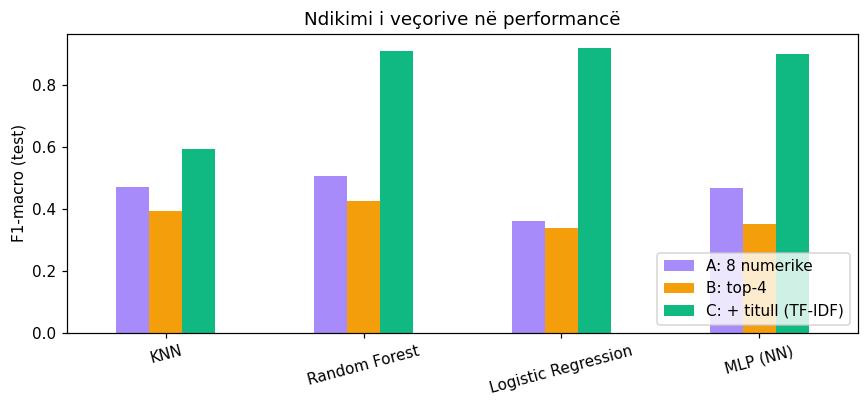

In [13]:
cmp = pd.DataFrame({
    'A: 8 numerike':[res_A[m]['f1'] for m in GRIDS],
    'B: top-4':[res_B[m]['f1'] for m in GRIDS],
    'C: + titull (TF-IDF)':[res_C[m]['f1'] for m in GRIDS],
}, index=list(GRIDS)).round(3)
display(cmp)
ax = cmp.plot(kind='bar', figsize=(8,3.8), color=['#a78bfa','#f59e0b','#10b981'])
ax.set_ylabel('F1-macro (test)'); ax.set_title('Ndikimi i veçorive në performancë')
ax.legend(loc='lower right'); plt.xticks(rotation=15); plt.tight_layout()
plt.savefig('figures/feature_comparison.png'); plt.show()
cmp.to_csv('results/feature_comparison.csv')

## 5. Vlerësimi përfundimtar — bashkësia më e mirë e veçorive (C)

Metrika: saktësia, precizioni, recall, F1 (macro) dhe matricat e konfuzionit për të katër klasifikuesit.

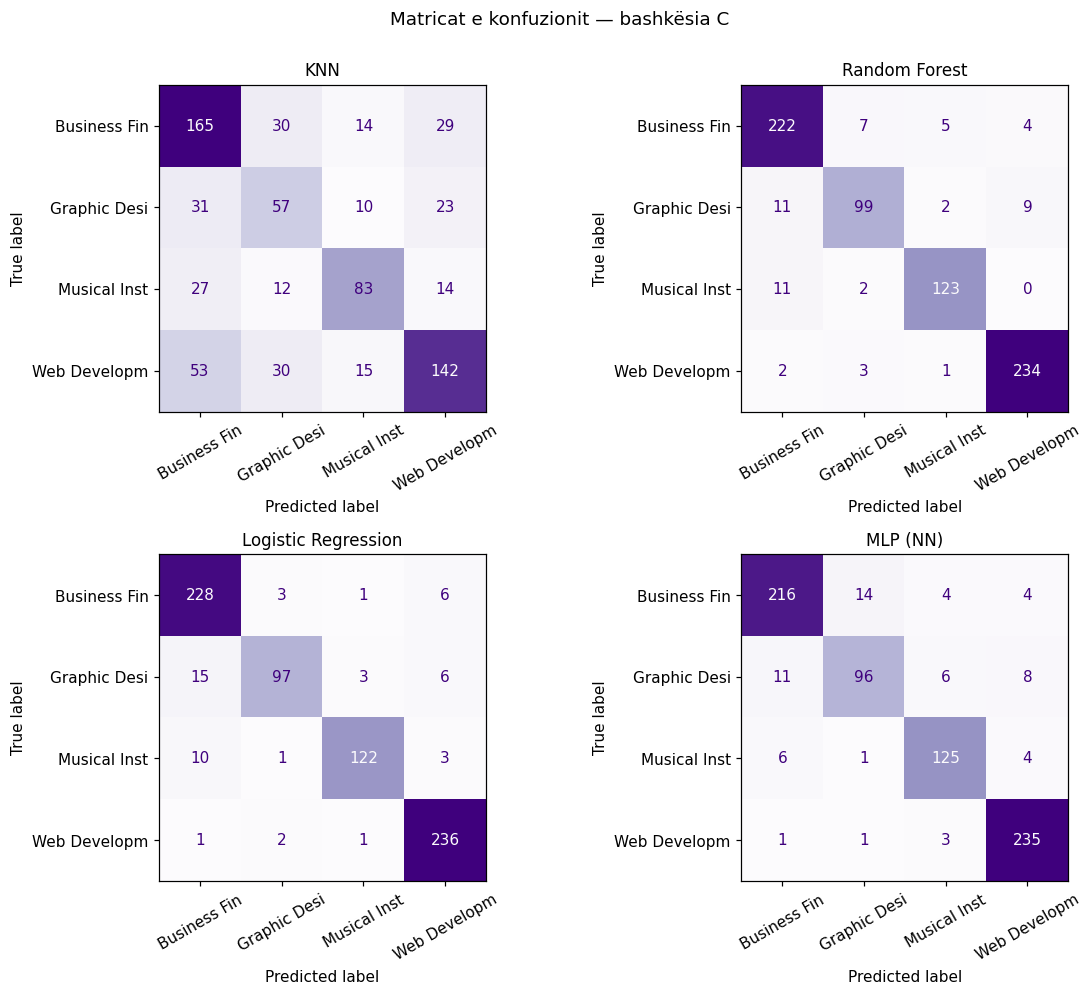

,Saktësia,Precizioni,Recall,F1,Hiperparametrat
Klasifikuesi,,,,,
KNN,0.6082,0.6007,0.5916,0.5938,"{'n_neighbors': 3, 'weights': 'distance'}"
Random Forest,0.9224,0.9202,0.9076,0.9133,"{'max_depth': None, 'n_estimators': 100}"
Logistic Regression,0.9293,0.9351,0.9100,0.9205,{'C': 10}
MLP (NN),0.9143,0.9056,0.8998,0.9022,"{'alpha': 0.0001, 'hidden_layer_sizes': (128, ..."


In [14]:
final_rows, best_models = [], {}
fig, axes = plt.subplots(2,2, figsize=(11,9))
for ax,(name,(est,grid)) in zip(axes.ravel(), GRIDS.items()):
    gs = GridSearchCV(est, grid, cv=3, scoring='f1_macro', n_jobs=-1).fit(Xc_tr, y_tr)
    pred = gs.predict(Xc_te); best_models[name] = gs.best_estimator_
    final_rows.append({'Klasifikuesi':name,
        'Saktësia':accuracy_score(y_te,pred), 'Precizioni':precision_score(y_te,pred,average='macro'),
        'Recall':recall_score(y_te,pred,average='macro'), 'F1':f1_score(y_te,pred,average='macro'),
        'Hiperparametrat':str(gs.best_params_)})
    cm = confusion_matrix(y_te, pred)
    ConfusionMatrixDisplay(cm, display_labels=[s[:12] for s in CLASS_NAMES]).plot(
        ax=ax, colorbar=False, cmap='Purples', xticks_rotation=30)
    ax.set_title(name, fontsize=11)
plt.suptitle('Matricat e konfuzionit — bashkësia C', y=1.0)
plt.tight_layout(); plt.savefig('figures/confusion_matrices.png'); plt.show()

final = pd.DataFrame(final_rows).set_index('Klasifikuesi').round(4)
display(final)
final.to_csv('results/final_results.csv')
RESULTS['final'] = final.to_dict('index')

### Eksperimenti me arkitekturat e rrjetës neurale

Krahasohen drejtpërdrejt dy arkitekturat e MLP me të njëjtat të dhëna (bashkësia C).

In [15]:
nn_rows = []
for arch in [(64,), (128,64)]:
    mlp = MLPClassifier(hidden_layer_sizes=arch, alpha=1e-4, max_iter=400,
                        early_stopping=True, random_state=RANDOM_STATE).fit(Xc_tr, y_tr)
    pred = mlp.predict(Xc_te)
    nn_rows.append({'Arkitektura':str(arch), 'Shtresa të fshehura':len(arch),
        'Saktësia':round(accuracy_score(y_te,pred),4),
        'F1-macro':round(f1_score(y_te,pred,average='macro'),4),
        'Iterime':mlp.n_iter_})
nn_df = pd.DataFrame(nn_rows).set_index('Arkitektura')
display(nn_df)
nn_df.to_csv('results/nn_architectures.csv')
RESULTS['nn_arch'] = nn_df.to_dict('index')

,Shtresa të fshehura,Saktësia,F1-macro,Iterime
Arkitektura,,,,
"(64,)",1,0.9102,0.9006,66
"(128, 64)",2,0.9143,0.9022,33


## 6. Grupimi (Clustering)

Etiketat `subject` **hiqen** — grupimi bëhet vetëm mbi veçoritë. Eksperimentohet me numrin e grupimeve k (metoda elbow + silueta), me metodën e inicializimit (`k-means++` vs `random`), dhe krahasohet K-Means me Agglomerative (Ward). Rezultatet vizualizohen me PCA 2D dhe krahasohen me etiketat reale (ARI, NMI).

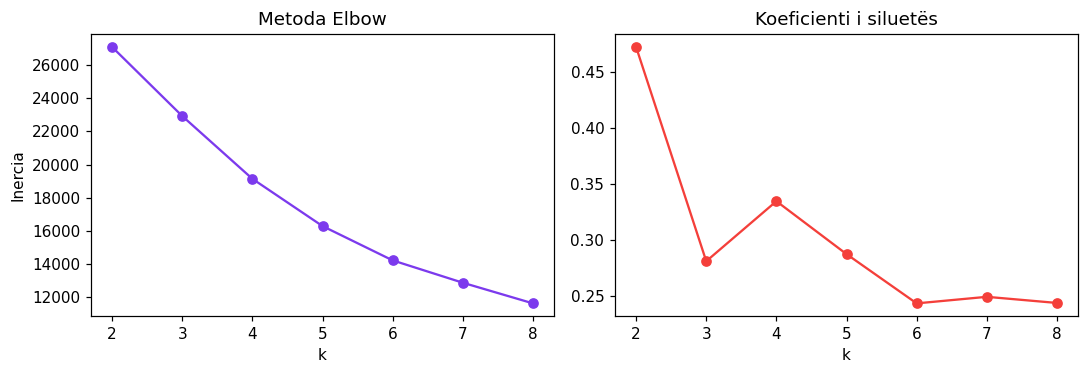

In [16]:
Xclu = np.vstack([Xc_tr, Xc_te])          # të gjitha veçoritë, PA etiketa
y_true_all = np.concatenate([y_tr, y_te])  # vetëm për vlerësim pas grupimit

inertias, sils = [], []
ks = range(2,9)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xclu)
    inertias.append(km.inertia_); sils.append(silhouette_score(Xclu, km.labels_))
fig, axes = plt.subplots(1,2, figsize=(10,3.5))
axes[0].plot(ks, inertias, 'o-', color='#7c3aed'); axes[0].set_title('Metoda Elbow'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[1].plot(ks, sils, 'o-', color='#f43f3a'); axes[1].set_title('Koeficienti i siluetës'); axes[1].set_xlabel('k')
plt.tight_layout(); plt.savefig('figures/elbow_silhouette.png'); plt.show()
RESULTS['silhouette'] = {int(k): round(s,4) for k,s in zip(ks, sils)}

In [17]:
# Eksperiment me inicializimin + krahasim algoritmesh, k=4 (sa klasat reale)
exps = {
 'KMeans k-means++': KMeans(4, init='k-means++', n_init=10, random_state=RANDOM_STATE),
 'KMeans random':    KMeans(4, init='random',    n_init=10, random_state=RANDOM_STATE),
 'Agglomerative (Ward)': AgglomerativeClustering(4),
}
clu_rows, labels_kpp = [], None
for name, alg in exps.items():
    lab = alg.fit_predict(Xclu)
    if labels_kpp is None: labels_kpp = lab
    clu_rows.append({'Algoritmi':name,
        'ARI':round(adjusted_rand_score(y_true_all, lab),4),
        'NMI':round(normalized_mutual_info_score(y_true_all, lab),4),
        'Silueta':round(silhouette_score(Xclu, lab),4)})
clu_df = pd.DataFrame(clu_rows).set_index('Algoritmi')
display(clu_df)
clu_df.to_csv('results/clustering_results.csv')
RESULTS['clustering'] = clu_df.to_dict('index')

,ARI,NMI,Silueta
Algoritmi,,,
KMeans k-means++,-0.0060,0.0254,0.3343
KMeans random,-0.0068,0.0252,0.3376
Agglomerative (Ward),-0.0043,0.0309,0.3362


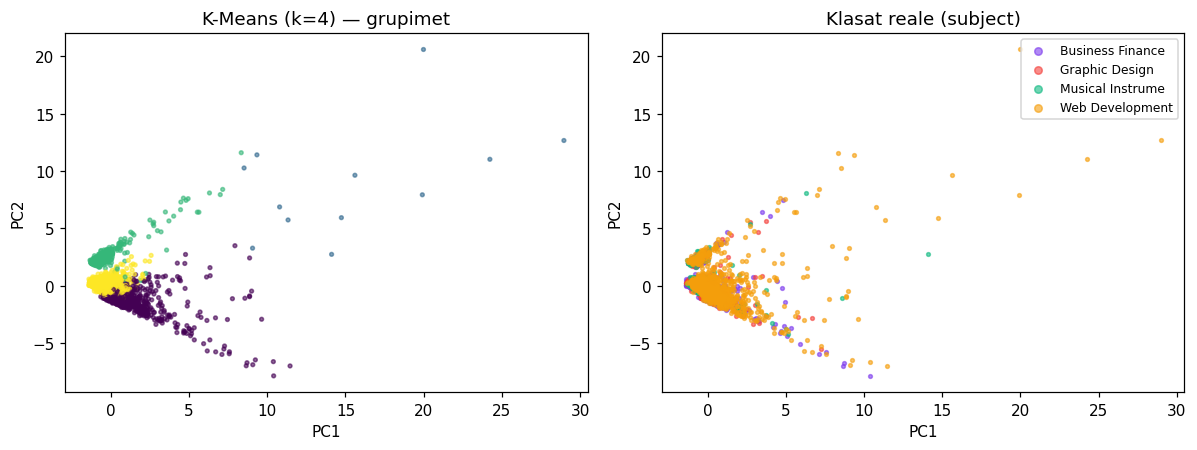

In [18]:
# Vizualizim PCA 2D: grupimet vs klasat reale
p2 = PCA(2, random_state=RANDOM_STATE).fit_transform(Xclu)
fig, axes = plt.subplots(1,2, figsize=(11,4.2))
axes[0].scatter(p2[:,0], p2[:,1], c=labels_kpp, cmap='viridis', s=6, alpha=.6)
axes[0].set_title('K-Means (k=4) — grupimet')
for si,c in zip(range(len(CLASS_NAMES)), ['#7c3aed','#f43f3a','#10b981','#f59e0b']):
    m = y_true_all==si
    axes[1].scatter(p2[m,0], p2[m,1], s=6, alpha=.6, label=CLASS_NAMES[si][:16], color=c)
axes[1].set_title('Klasat reale (subject)'); axes[1].legend(markerscale=2, fontsize=8)
for ax in axes: ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.savefig('figures/clusters_pca.png'); plt.show()

In [19]:
# Eksperiment shtesë: grupimi VETËM mbi veçoritë tekstuale (SVD të titullit)
# Hipoteza: lënda e kursit shprehet te titulli, jo te shkalla e popullaritetit
Xtext = np.vstack([Xc_tr[:,8:], Xc_te[:,8:]])   # vetëm 50 komponentët SVD
km_t = KMeans(4, n_init=10, random_state=RANDOM_STATE).fit(Xtext)
print('Vetëm tekst:  ARI =', round(adjusted_rand_score(y_true_all, km_t.labels_),4),
      '| NMI =', round(normalized_mutual_info_score(y_true_all, km_t.labels_),4))
print('Të gjitha veçoritë: ARI =', RESULTS['clustering']['KMeans k-means++']['ARI'],
      '| NMI =', RESULTS['clustering']['KMeans k-means++']['NMI'])
RESULTS['clustering_text_only'] = {
    'ARI': round(adjusted_rand_score(y_true_all, km_t.labels_),4),
    'NMI': round(normalized_mutual_info_score(y_true_all, km_t.labels_),4)}

Vetëm tekst:  ARI = 0.1337 | NMI = 0.3335
Të gjitha veçoritë: ARI = -0.006 | NMI = 0.0254


In [20]:
# Tabela e kontingjencës: cili grup i përgjigjet cilës klasë
cont = pd.crosstab(pd.Series(km_t.labels_, name='Grupi (tekst)'),
                   pd.Series(le.inverse_transform(y_true_all), name='Klasa reale'))
display(cont)
cont.to_csv('results/contingency.csv')
RESULTS['contingency'] = cont.to_dict()
with open('results/all_results.json','w') as f: json.dump(RESULTS, f, indent=2, default=str)
print('Të gjitha rezultatet u ruajtën në results/')

Klasa reale,Business Finance,Graphic Design,Musical Instruments,Web Development
Grupi (tekst),,,,
0,3,11,2,641
1,895,425,418,557
2,2,166,260,1
3,291,0,0,0


Të gjitha rezultatet u ruajtën në results/


## 7. Përfundime

- **Veçoritë tekstuale janë vendimtare:** vetëm me veçori numerike klasifikimi është i kufizuar; shtimi i titullit (TF-IDF + SVD) e rrit ndjeshëm F1 për të gjithë klasifikuesit — titulli mbart informacionin më të fortë për lëndën.
- **Përzgjedhja e veçorive:** SelectKBest tregon se pak veçori numerike (sidomos çmimi dhe metrikat e popullaritetit) mbartin pjesën më të madhe të sinjalit numerik, por nuk mjaftojnë pa tekstin.
- **Rrjeta neurale:** arkitektura më e thellë `(128,64)` jep përmirësim të lehtë ndaj `(64,)`, me kosto trajnimi pak më të lartë — për këtë madhësi dataseti, diferenca është e moderuar.
- **Grupimi — gjetje e papritur:** mbi të gjitha veçoritë, K-Means formon grupe sipas *shkallës së popullaritetit* të kursit (numri i studentëve/recensioneve), jo sipas lëndës — ARI ≈ 0. Kur grupimi bëhet vetëm mbi veçoritë tekstuale të titullit, përputhja me klasat reale rritet ndjeshëm (shih ARI/NMI më sipër). Kjo tregon se "struktura natyrore" e një dataseti varet nga hapësira e veçorive: tregu i kurseve ndahet natyrshëm në "hite" dhe "kurse të vogla", ndërsa lënda lexohet vetëm përmes tekstit.